In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils
from hbn.data import data_utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
vis.plotting_style()

In [3]:
## visualize functions

# FUNCTIONS
def plot_bar(df, x='features', hue=None, plot_null=True, ax=None):

    # plot data
    data = df[df['data']=='data']
    fig = vis.barplot(
                data=data, 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4),
                ax=ax
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

def plot_line(df, x='readers', hue=None, plot_null=True, ax=None):
    fig = vis.pointplot(
                data=df[df['data']=='data'].sort_values(by=['features'], ascending=False), 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                figsize=(6,4),
                ax=ax
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig


def get_missingness(summary, dx_col='DX_ADHD'):
    all_features = summary['features'].unique()

    out = {}
    for dx in summary[dx_col].unique():

        for sex in summary['Sex'].unique():

            # get models that have been run
            check_models =summary[(summary[dx_col]==dx) & (summary['Sex']==sex)]['features'].unique()

            models_to_run = list(set(all_features) - set(check_models))

            out.update({f'{dx}-{sex}': models_to_run})
    
    return out


## load data
def get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype'):
    # load data for all models run in `model_parent`
    summary, _ = data_utils.load_model_results(model=model)

    # remap diagnosis
    summary[dx] = summary[dx].map(utils.remap_dx())

    # check missingness of models (which models need to be rerun)
    out_models = get_missingness(summary, dx_col=dx)
    print(out_models)

    # make new cols
    summary['assessment'] = summary['features'].str.extract('(teacher|child|parent)')
    if not 'teacher|child|parent' in summary['features']:
        summary['assessment'] = 'all'
    summary['features'] = summary['features'].str.replace('teacher-', '').str.replace('child-', '').str.replace('parent-', '')

    # add new cols for assessment
    def map_assessment(x):
        data_dict = {
            'CBCL': ['externalizing', 'internalizing', 'anxious_depressed', 'rule_breaking',
                    'aggressive_behavior', 'withdrawn_depressed', 'social_problems',
                    'somatic_complaints', 'thought_problems', 'attention_problems'],
            'C3SR': ['defiance_aggression', 'family_relations', 'hyperactive_impulsivity', 'inattention',
                    'learning_problems', 'negative_impression', 'positive_impression'],
            'suicidality': ['suicidality'],
            'demos': ['demos-excl-sex'],
            'SWAN': ['swan_hyperactive', 'swan_inattention'],
        }
        for k,v in data_dict.items():
            if x in v:
                return k
            else:
                return x

    summary['measure'] = summary['features'].apply(lambda x: map_assessment(x))

    return summary

def ttest_ind(group1, group2):
    import scipy.stats as stats

    # Assuming normality within each group
    statistic, p_value = stats.ttest_ind(group1, group2)

    # Interpret the results
    alpha = 0.05  # Significance level
    print("T-statistic:", statistic)
    print("P-value:", p_value)

def stat_test(df, feature='attention_problems'):
    group1 = df[(df['Sex']=='male') & \
             (df['features']==feature) & \
             (df['assessment']=='parent') & \
             (df['data']=='data')] \
             ['roc_auc_score']

    group2 = df[(df['Sex']=='female') & \
                (df['features']==feature) & \
                (df['assessment']=='parent') & \
                (df['data']=='data')] \
                ['roc_auc_score']

    ttest_ind(group1, group2)



## Models - Subscales

In [38]:
## FUNCTIONS

def fig1A(ax, 
          summary, 
          subplot='A', 
          feature='selected_all', 
          hue=None, 
          x='features',
          Race=['all'],  
          target='DX', 
          target_cols=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
          features=None, 
          measure=None,
          assessment=['child', 'parent', 'teacher'], 
          sex=['male_female']
          ):
        
        # grab features if measure is given
        if (measure is not None) and (features is None):
            summary = summary[summary['measure'].isin(measure)]
            features = summary['features'].unique()

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}'],
                        target: target_cols,
                        'development': ['all'],
                        'data': ['data'],
                        'features': features,
                        'assessment': assessment,
                        'Race': Race,
                        }

        # filter dataframe
        df_data = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot data
        vis.barplot(data=df_data.sort_values(by='Sex'), 
                    x=x, ax=ax, subplot=subplot, hue=hue,
                    )

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_null = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_null['roc_auc_score'].mean(), color='k', linestyle='--')

        return df_data


def fig1B(ax,           
          summary, 
          subplot='A', 
          feature='selected_all', 
          hue=None, 
          Race=['all'],  
          target='DX', 
          development=['5-11', '12-17'],
          target_cols=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
          features=None, 
          measure=None,
          assessment=['child', 'parent', 'teacher'], 
          sex=['male_female']):

        # grab features if measure is given
        if (measure is not None) and (features is None):
            summary = summary[summary['measure'].isin(measure)]
            features = summary['features'].unique()

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}'],
                        target: target_cols,
                        'development': development,
                        'data': ['data'],
                        'features': features,
                        'assessment': assessment,
                        'Race': Race,
                        }

        # filter dataframe
        df_data = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        vis.pointplot(data=df_data.sort_values(by=['Sex']), 
                        x='development', 
                        hue=hue, 
                        order=development,
                        ax=ax, 
                        ylim=[0.4, 1.05],
                        subplot=subplot
                        )

        default_params.update({'data': ['null']})

        # filter dataframe to just 1 feature
        df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot reading model
        ax.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

        return df_data


def fig1C(ax, 
          df, 
          subplot='A', 
          feature='selected_all', 
          hue=None, 
          x='feature_importances',
          y='key',
          Race=['all'],  
          target='DX', 
          development=['5-11', '12-17'],
          target_cols=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
          features=None,  
          sex=['male_female'],
          title=''
          ):

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}'],
                        target: target_cols,
                        'development': development,
                        'features': features,
                        'Race': Race,
                        }

        # filter dataframe
        df_data = utils.filter_train(df, columns=list(default_params.keys()), values=list(default_params.values()))

        # plot data
        vis.plot_features_subplot(
                          df=df_data, 
                          colors=None,
                          x=x, 
                          y=y, 
                          hue=hue,
                          top_features=10,
                          ax=ax,
                          topic_labels=False,
                          title=title,
                          subplot=subplot
                          )

        return df_data

def fig1D(ax, 
          df, 
          x='Sex',
          subplot='A', 
          feature='selected_all', 
          Race=['all'],  
          target='DX', 
          development=['5-11', '12-17'],
          target_cols=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],
          features=None,  
          ylabel='Overall features (%)',
          sex=['male_female'],
          color_dict=None,
          ):

        default_params = {'Sex': sex,
                        'feature_threshold': [f'{feature}'],
                        target: target_cols,
                        'development': development,
                        'features': features,
                        'Race': Race,
                        }

        # filter and stack dataframe
        df_data = utils.filter_train(df, columns=list(default_params.keys()), values=list(default_params.values()))
        df_stacked = pd.pivot(df_data, index=x, columns='key', values='perc')

        # assign colors according to `color_dict`
        colors = None
        if color_dict is not None:
          colors = []
          for key in df_stacked.columns:
            colors.append(color_dict[key])

        # plot data
        ax = vis.plot_stacked(
            df=df_stacked, 
            ylabel=ylabel,
            colors=colors,
            ax=ax,
            subplot=subplot
            )

        return ax

## Classifying Diagnosis - ADHD vs. No Diagnosis SUBSCALES

{'ADHD (Combined Type)-male_female': ['parent-externalizing', 'child-hyperactive_impulsivity'], 'ADHD (Combined Type)-male': [], 'ADHD (Combined Type)-female': [], 'ADHD (Inattentive Type)-male_female': ['child-learning_problems', 'parent-somatic_complaints', 'parent-internalizing', 'child-somatic_complaints', 'parent-attention_problems'], 'ADHD (Inattentive Type)-male': ['child-positive_impression', 'child-thought_problems', 'child-hyperactive_impulsivity', 'child-withdrawn_depressed', 'teacher-withdrawn_depressed', 'teacher-somatic_complaints', 'child-swan_hyperactive', 'parent-aggressive_behavior', 'child-internalizing', 'child-somatic_complaints'], 'ADHD (Inattentive Type)-female': ['teacher-rule_breaking']}
T-statistic: 4.296523529975836
P-value: 0.00043443276702384077
T-statistic: 0.8637924945747555
P-value: 0.39504136721592076
{'ADHD (all comorbid.)-male': ['child-defiance_aggression', 'teacher-internalizing'], 'ADHD (all comorbid.)-female': ['teacher-anxious_depressed', 'teache

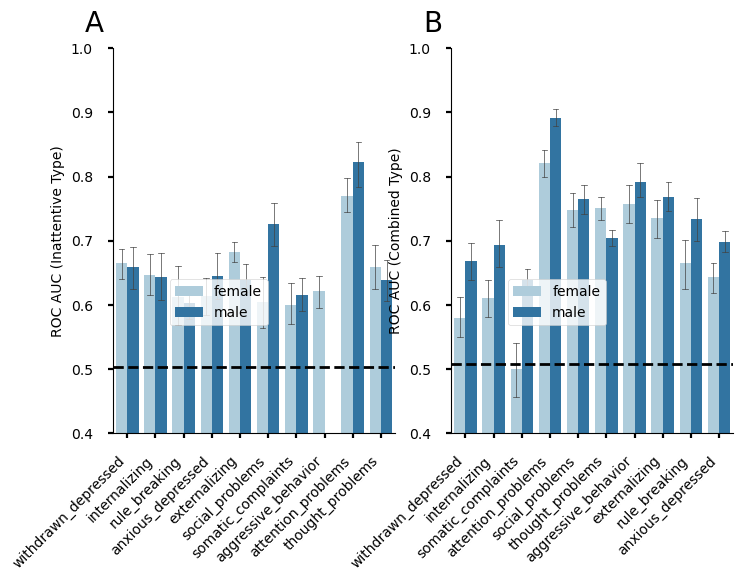

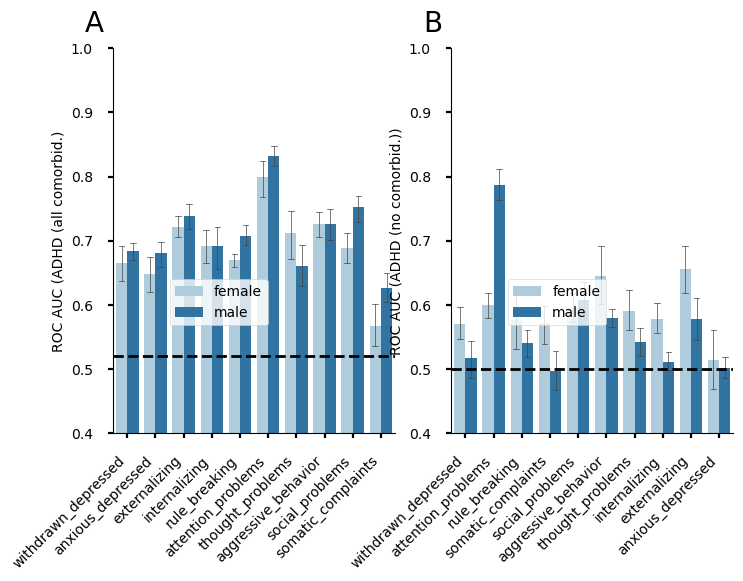

In [27]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary1 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Inattentive Type)'],
    measure=['CBCL'],
    # features=['attention_problems', 'social_problems'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (Inattentive Type)')
stat_test(out, feature='social_problems')


# # 1B
ax = fig.add_subplot(gs[0, 1])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Combined Type)'],
    measure=['CBCL'],
    # features=['attention_problems', 'social_problems'],
    assessment=['parent'],
    subplot='B',
    ) 
ax.set_ylabel('ROC AUC (Combined Type)')
stat_test(out, feature='social_problems')

# fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.2, wspace=.3, hspace=.5)

vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary2 = get_data(dx='DX_ADHD', model='adhd_october_dx')

# # 1C
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary2, 
    sex=['female', 'male'], 
    target='DX_ADHD', 
    hue='Sex', 
    target_cols=['ADHD (all comorbid.)'],
    measure=['CBCL'],
    # features=['attention_problems', 'social_problems'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (ADHD (all comorbid.)')
stat_test(out, feature='social_problems')

# # 1C
ax = fig.add_subplot(gs[0, 1])
out = fig1A(ax, 
    summary2, 
    sex=['female', 'male'], 
    target='DX_ADHD', 
    hue='Sex', 
    target_cols=['ADHD (no comorbid.)'],
    measure=['CBCL'],
    # features=['attention_problems', 'social_problems'],
    assessment=['parent'],
    subplot='B'
    ) 
ax.set_ylabel('ROC AUC (ADHD (no comorbid.))')
stat_test(out, feature='social_problems')

# fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.2, wspace=.3, hspace=.5)
# # fig.savefig(os.path.join(Defaults.FIG_DIR, f'fig2.png'), bbox_inches='tight')

T-statistic: 4.964939995701589
P-value: 9.08324569107436e-06


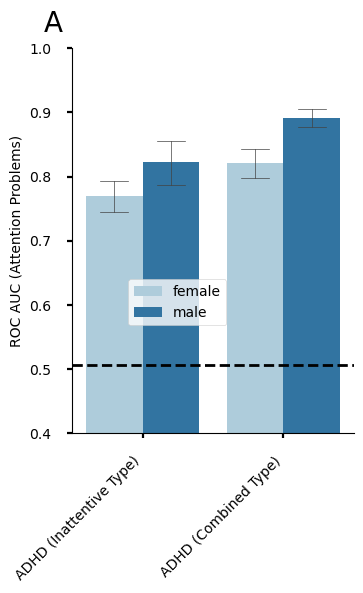

In [28]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
# summary1 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    x='DX_Subtype_Name',
    target_cols=['ADHD (Inattentive Type)', 'ADHD (Combined Type)'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (Attention Problems)')
stat_test(out, feature='attention_problems')

T-statistic: nan
P-value: nan


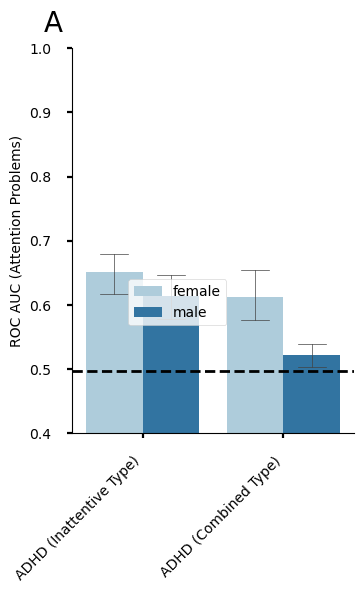

In [36]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
# summary1 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    x='DX_Subtype_Name',
    target_cols=['ADHD (Inattentive Type)', 'ADHD (Combined Type)'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['child'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (Attention Problems)')
stat_test(out, feature='attention_problems')    

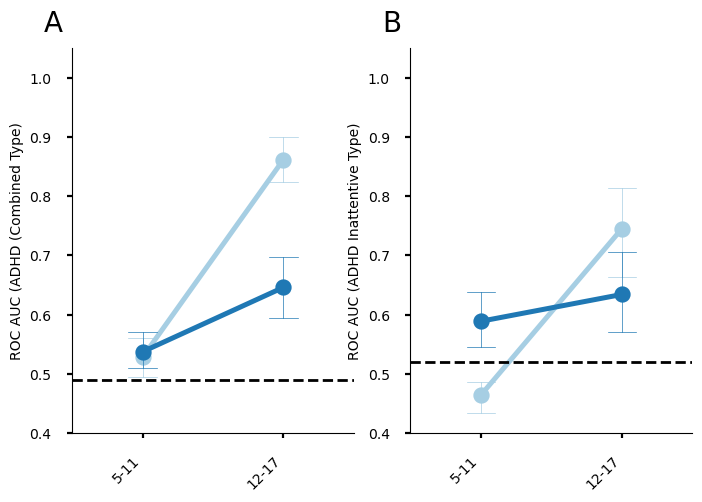

In [37]:
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
# summary3 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype_age')

# # 1C
ax = fig.add_subplot(gs[0, 0])
out = fig1B(ax, 
    summary3, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Combined Type)'],
    development=['5-11', '12-17'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['child'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (ADHD (Combined Type)')
ax.get_legend().remove()
# stat_test(out, feature='social_problems')

# # 1C
ax = fig.add_subplot(gs[0, 1])
out = fig1B(ax, 
    summary3, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Inattentive Type)'],
    development=['5-11', '12-17'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['child'],
    subplot='B'
    ) 
ax.set_ylabel('ROC AUC (ADHD Inattentive Type)')
ax.get_legend().remove()
# stat_test(out, feature='social_problems')

## Classifying Diagnosis - QUESTIONNAIRES (NO SUBSCALES)

{'ADHD (Combined Type)-male': [], 'ADHD (Combined Type)-female': [], 'ADHD (Inattentive Type)-male': [], 'ADHD (Inattentive Type)-female': []}


Text(0, 0.5, 'ROC AUC (CBCL - child)')

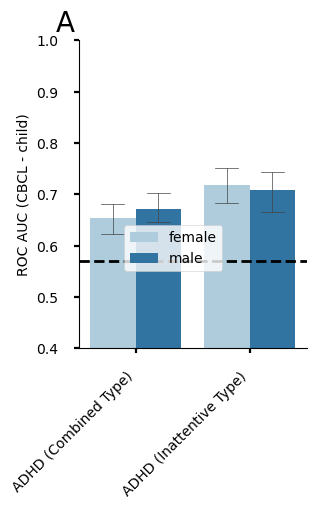

In [38]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(10,4))
gs = GridSpec(1, 3, figure=fig)

# get data
summary1 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype_questionnaires')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    x='DX_Subtype_Name',
    target_cols=['ADHD (Inattentive Type)', 'ADHD (Combined Type)'],
    measure=['mood'],
    assessment=['child'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (CBCL - child)')


{'ADHD (Combined Type)-male': [], 'ADHD (Combined Type)-female': [], 'ADHD (Inattentive Type)-male': [], 'ADHD (Inattentive Type)-female': []}


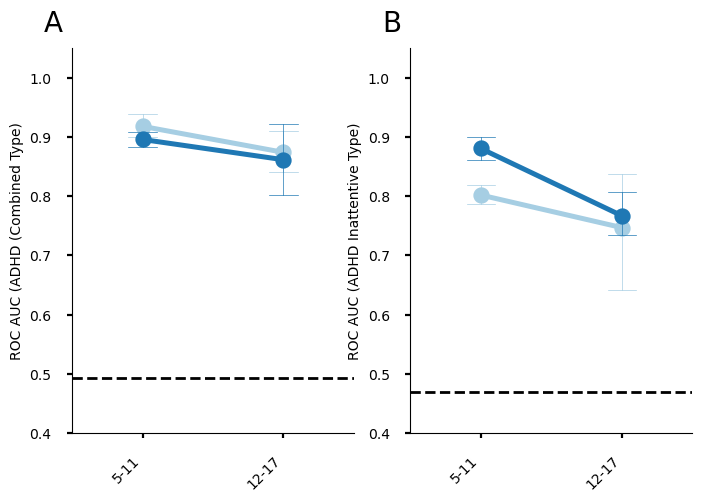

In [36]:
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary3 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype_questionnaires')

# # 1C
ax = fig.add_subplot(gs[0, 0])
out = fig1B(ax, 
    summary3, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Combined Type)'],
    development=['5-11', '12-17'],
    measure=['cbcl'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (ADHD (Combined Type)')
ax.get_legend().remove()
# stat_test(out, feature='social_problems')

# # 1C
ax = fig.add_subplot(gs[0, 1])
out = fig1B(ax, 
    summary3, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Inattentive Type)'],
    development=['5-11', '12-17'],
    measure=['cbcl'],
    assessment=['parent'],
    subplot='B'
    ) 
ax.set_ylabel('ROC AUC (ADHD Inattentive Type)')
ax.get_legend().remove()
# stat_test(out, feature='social_problems')

{'ADHD (Combined Type)-male': [], 'ADHD (Combined Type)-female': [], 'ADHD (Inattentive Type)-male': [], 'ADHD (Inattentive Type)-female': []}


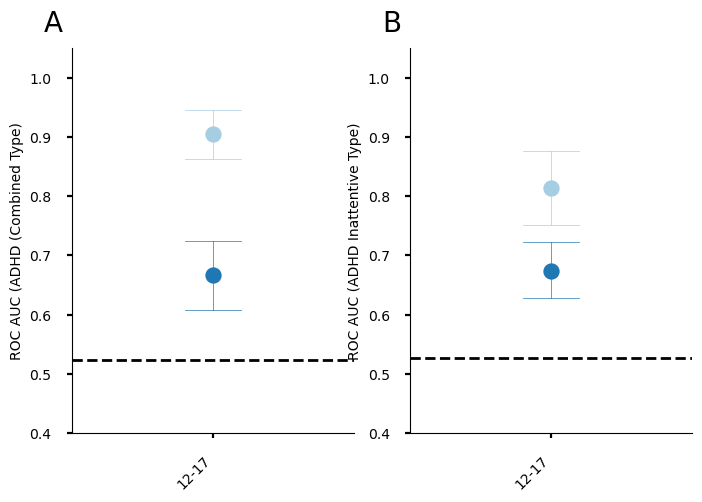

In [39]:
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary3 = get_data(dx='DX_Subtype_Name', model='adhd_october_dx_subtype_questionnaires')

# # 1C
ax = fig.add_subplot(gs[0, 0])
out = fig1B(ax, 
    summary3, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Combined Type)'],
    development=['12-17'],
    measure=['cbcl'],
    assessment=['child'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (ADHD (Combined Type)')
ax.get_legend().remove()
# stat_test(out, feature='social_problems')

# # 1C
ax = fig.add_subplot(gs[0, 1])
out = fig1B(ax, 
    summary3, 
    sex=['female', 'male'], 
    target='DX_Subtype_Name', 
    hue='Sex', 
    target_cols=['ADHD (Inattentive Type)'],
    development=['12-17'],
    measure=['cbcl'],
    assessment=['child'],
    subplot='B'
    ) 
ax.set_ylabel('ROC AUC (ADHD Inattentive Type)')
ax.get_legend().remove()
# stat_test(out, feature='social_problems')

## Classifying Diagnosis - ADHD vs. Depression 

{'ADHD (Combined Type) (no Depression)-female': [], 'ADHD (Combined Type) (no Depression)-male': [], 'ADHD (Inattentive Type) (no Depression)-female': [], 'ADHD (Inattentive Type) (no Depression)-male': []}
T-statistic: -10.746233186627071
P-value: 2.655891712058095e-16


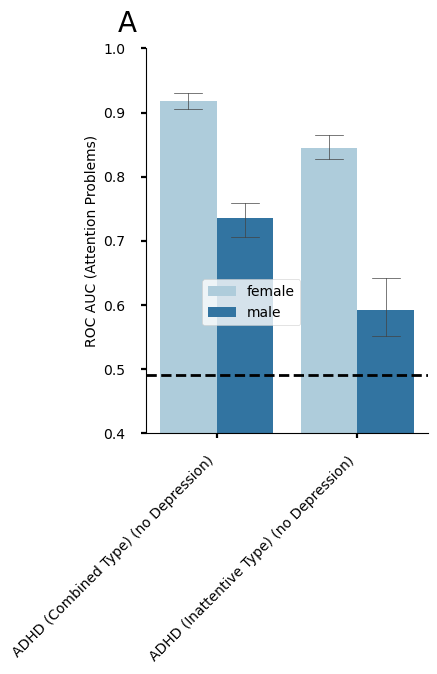

In [32]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary1 = get_data(dx='DX_Depression', model='adhd_october_dx_subtype_depression')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Depression', 
    hue='Sex', 
    x='DX_Depression',
    target_cols=['ADHD (Inattentive Type) (no Depression)', 'ADHD (Combined Type) (no Depression)'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (Attention Problems)')
stat_test(out, feature='attention_problems')

{'ADHD (Combined Type) (no Anxiety)-female': [], 'ADHD (Combined Type) (no Anxiety)-male': [], 'ADHD (Inattentive Type) (no Anxiety)-female': [], 'ADHD (Inattentive Type) (no Anxiety)-male': []}
T-statistic: -1.89674888780473
P-value: 0.0654814743921029


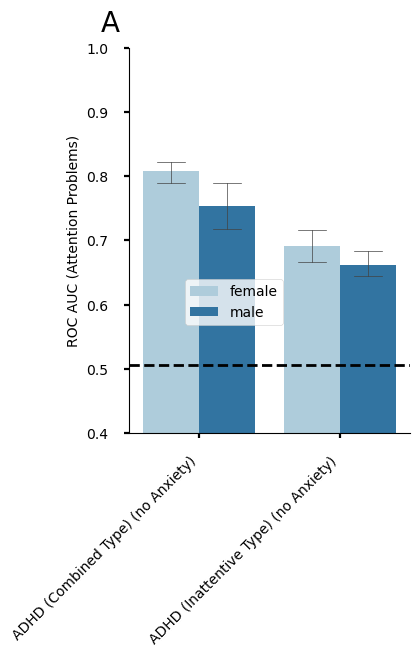

In [31]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary1 = get_data(dx='DX_Anxiety', model='adhd_october_dx_subtype_anxiety')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Anxiety', 
    hue='Sex', 
    x='DX_Anxiety',
    target_cols=['ADHD (Inattentive Type) (no Anxiety)', 'ADHD (Combined Type) (no Anxiety)'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (Attention Problems)')
stat_test(out, feature='attention_problems')

{'ADHD (Combined Type) (no Anxiety)-female': [], 'ADHD (Combined Type) (no Anxiety)-male': [], 'ADHD (Inattentive Type) (no Anxiety)-female': [], 'ADHD (Inattentive Type) (no Anxiety)-male': []}
T-statistic: -1.89674888780473
P-value: 0.0654814743921029


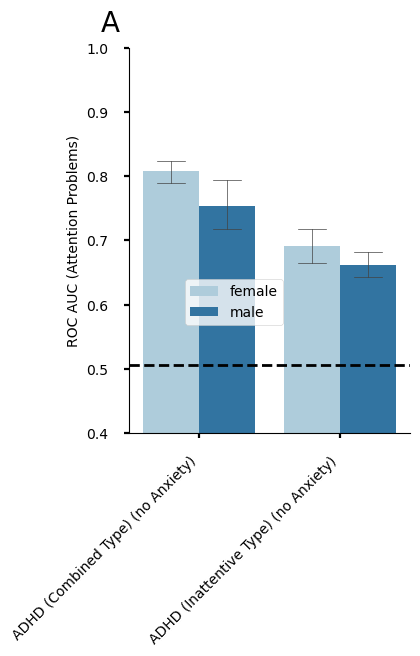

In [25]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
summary1 = get_data(dx='DX_Anxiety', model='adhd_october_dx_subtype_anxiety')

# 1A
ax = fig.add_subplot(gs[0, 0])
out = fig1A(ax, 
    summary1, 
    sex=['female', 'male'], 
    target='DX_Anxiety', 
    hue='Sex', 
    x='DX_Anxiety',
    target_cols=['ADHD (Inattentive Type) (no Anxiety)', 'ADHD (Combined Type) (no Anxiety)'],
    measure=['CBCL'],
    features=['attention_problems'],
    assessment=['parent'],
    subplot='A'
    ) 
ax.set_ylabel('ROC AUC (Attention Problems)')
stat_test(out, feature='attention_problems')

### All feature models (pre and post pubertal)

{'ADHD (all comorbid.)-male_female': [], 'ADHD (all comorbid.)-male': [], 'ADHD (all comorbid.)-female': []}


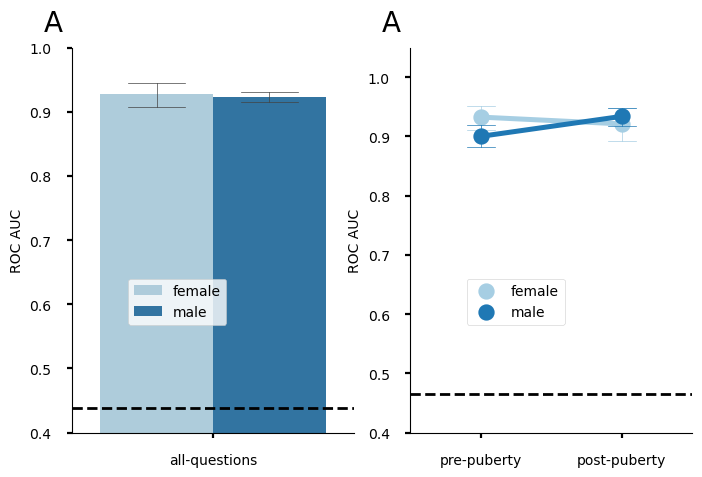

In [83]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_ADHD'
model = 'december_adhd_dx'
summary  = get_data(dx=dx, model=model);

# 1A
ax = fig.add_subplot(gs[0, 0])
fig1A(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    Race=['all'],  
    target='DX_ADHD', 
    target_cols=['ADHD (all comorbid.)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );

ax = fig.add_subplot(gs[0, 1])
fig1B(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    Race=['all'],  
    target='DX_ADHD', 
    development=['pre-puberty', 'post-puberty'],
    target_cols=['ADHD (all comorbid.)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );

{'ADHD (all comorbid.)-male_female': [], 'ADHD (all comorbid.)-male': [], 'ADHD (all comorbid.)-female': [], 'ADHD (no comorbid.)-male_female': [], 'ADHD (no comorbid.)-male': [], 'ADHD (no comorbid.)-female': [], 'nan-male_female': ['all-questions'], 'nan-male': ['all-questions'], 'nan-female': ['all-questions']}


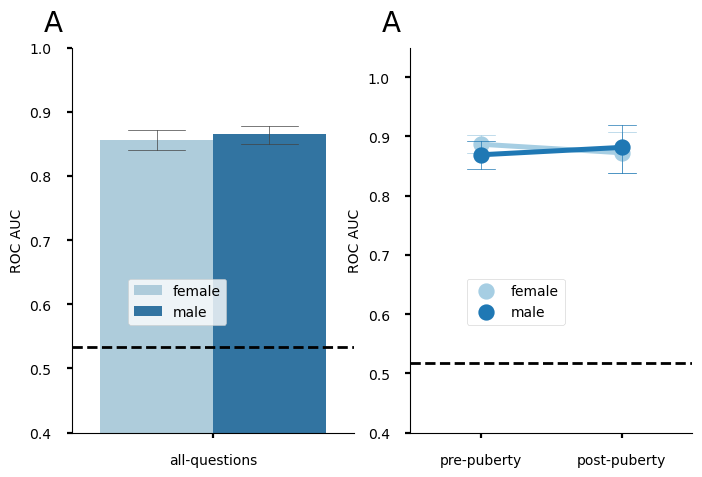

In [14]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_ADHD'
model = 'december_adhd_dx'
summary  = get_data(dx=dx, model=model);

# 1A
ax = fig.add_subplot(gs[0, 0])
fig1A(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    Race=['all'],  
    target='DX_ADHD', 
    target_cols=['ADHD (no comorbid.)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );

ax = fig.add_subplot(gs[0, 1])
fig1B(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    Race=['all'],  
    target='DX_ADHD', 
    development=['pre-puberty', 'post-puberty'],
    target_cols=['ADHD (no comorbid.)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );

{'nan-male_female': ['all-questions'], 'nan-male': ['all-questions'], 'nan-female': ['all-questions'], 'ADHD (Combined Type)-male_female': [], 'ADHD (Combined Type)-male': [], 'ADHD (Combined Type)-female': [], 'ADHD (Inattentive Type)-male_female': [], 'ADHD (Inattentive Type)-male': [], 'ADHD (Inattentive Type)-female': []}


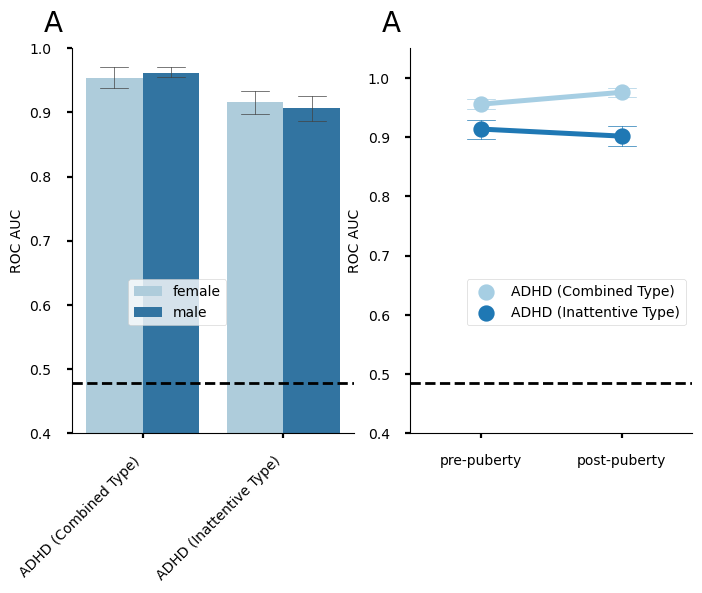

In [17]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_Subtype_Name'
model = 'december_adhd_dx'
summary  = get_data(dx=dx, model=model);

# 1A
ax = fig.add_subplot(gs[0, 0])
fig1A(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    x=dx,
    Race=['all'],  
    target=dx, 
    target_cols=['ADHD (Combined Type)', 'ADHD (Inattentive Type)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );
plt.xticks(rotation=45, ha='right');

ax = fig.add_subplot(gs[0, 1])
fig1B(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue=dx, 
    Race=['all'],  
    target=dx, 
    development=['pre-puberty', 'post-puberty'],
    target_cols=['ADHD (Combined Type)', 'ADHD (Inattentive Type)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male_female']
    );

{'nan-male_female': ['all-questions'], 'nan-male': ['all-questions'], 'nan-female': ['all-questions'], 'ADHD (Combined Type)-male_female': [], 'ADHD (Combined Type)-male': [], 'ADHD (Combined Type)-female': [], 'ADHD (Inattentive Type)-male_female': [], 'ADHD (Inattentive Type)-male': [], 'ADHD (Inattentive Type)-female': []}


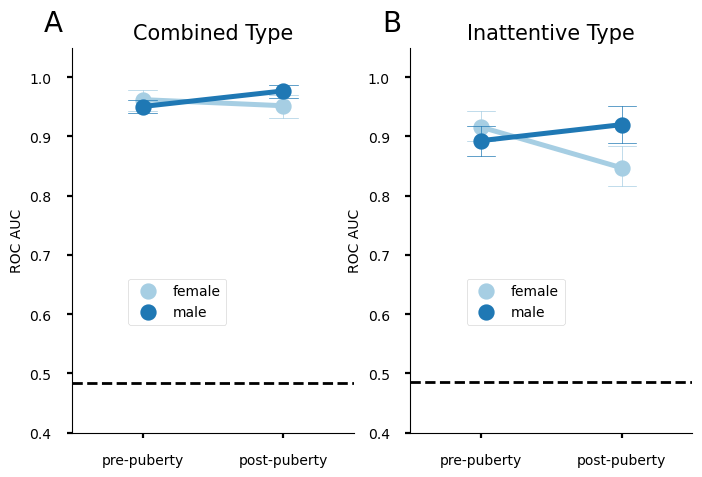

In [15]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_Subtype_Name'
model = 'december_adhd_dx'
summary  = get_data(dx=dx, model=model);

# 1A
ax = fig.add_subplot(gs[0, 0])
fig1B(ax,           
    summary, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    Race=['all'],  
    target=dx, 
    development=['pre-puberty', 'post-puberty'],
    target_cols=['ADHD (Combined Type)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );
plt.title('Combined Type');

ax = fig.add_subplot(gs[0, 1])
fig1B(ax,           
    summary, 
    subplot='B', 
    feature='selected_all', 
    hue='Sex', 
    Race=['all'],  
    target=dx, 
    development=['pre-puberty', 'post-puberty'],
    target_cols=['ADHD (Inattentive Type)'],
    features=['all-questions'], 
    measure=None,
    assessment=['all'], 
    sex=['male', 'female']
    );
plt.title('Inattentive Type');

### Feature Interpretation

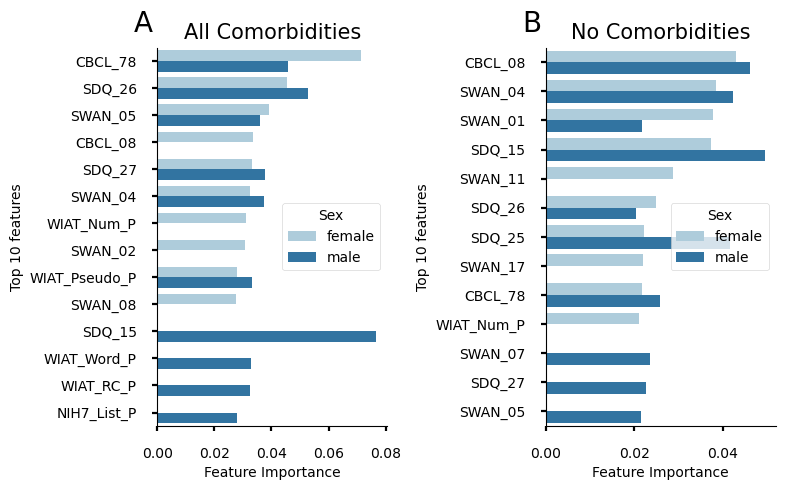

In [6]:
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_ADHD'
model = 'december_adhd_dx'
features = data_utils.load_model_features(model=model);

ax = fig.add_subplot(gs[0, 0])
df_data = fig1C(ax, 
    features, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    x='feature_importances',
    y='feature_names',
    Race=['all'],  
    target=dx, 
    development=['all'],
    target_cols=['ADHD (all comorbid.)'],
    features=['all-questions'], 
    sex=['male', 'female'],
    title='All Comorbidities'
    );

ax = fig.add_subplot(gs[0, 1])
df_data = fig1C(ax, 
    features, 
    subplot='B', 
    feature='selected_all', 
    hue='Sex', 
    x='feature_importances',
    y='feature_names',
    Race=['all'],  
    target=dx, 
    development=['all'],
    target_cols=['ADHD (no comorbid.)'],
    features=['all-questions'], 
    sex=['male', 'female'],
    title='No Comorbidities'
    );

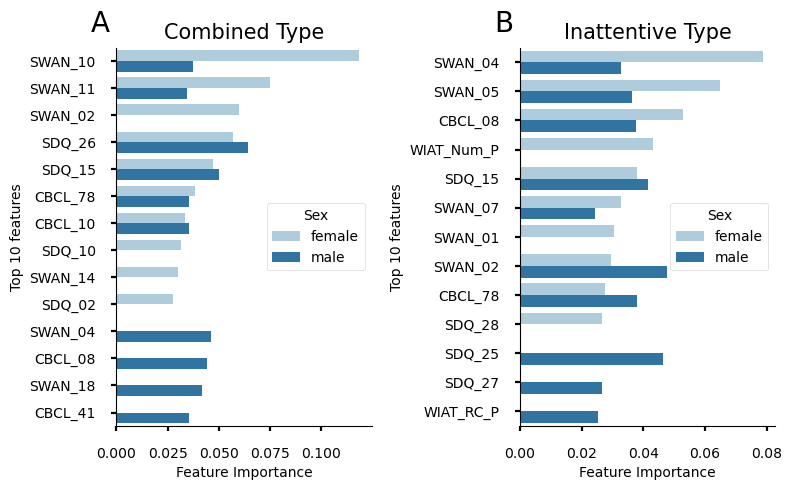

In [5]:
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_Subtype_Name'
model = 'december_adhd_dx'
features = data_utils.load_model_features(model=model);

ax = fig.add_subplot(gs[0, 0])
df_data = fig1C(ax, 
    features, 
    subplot='A', 
    feature='selected_all', 
    hue='Sex', 
    x='feature_importances',
    y='feature_names',
    Race=['all'],  
    target=dx, 
    development=['all'],
    target_cols=['ADHD (Combined Type)'],
    features=['all-questions'], 
    sex=['male', 'female'],
    title='Combined Type'
    );

ax = fig.add_subplot(gs[0, 1])
df_data = fig1C(ax, 
    features, 
    subplot='B', 
    feature='selected_all', 
    hue='Sex', 
    x='feature_importances',
    y='feature_names',
    Race=['all'],  
    target=dx, 
    development=['all'],
    target_cols=['ADHD (Inattentive Type)'],
    features=['all-questions'], 
    sex=['male', 'female'],
    title='Inattentive Type'
    );

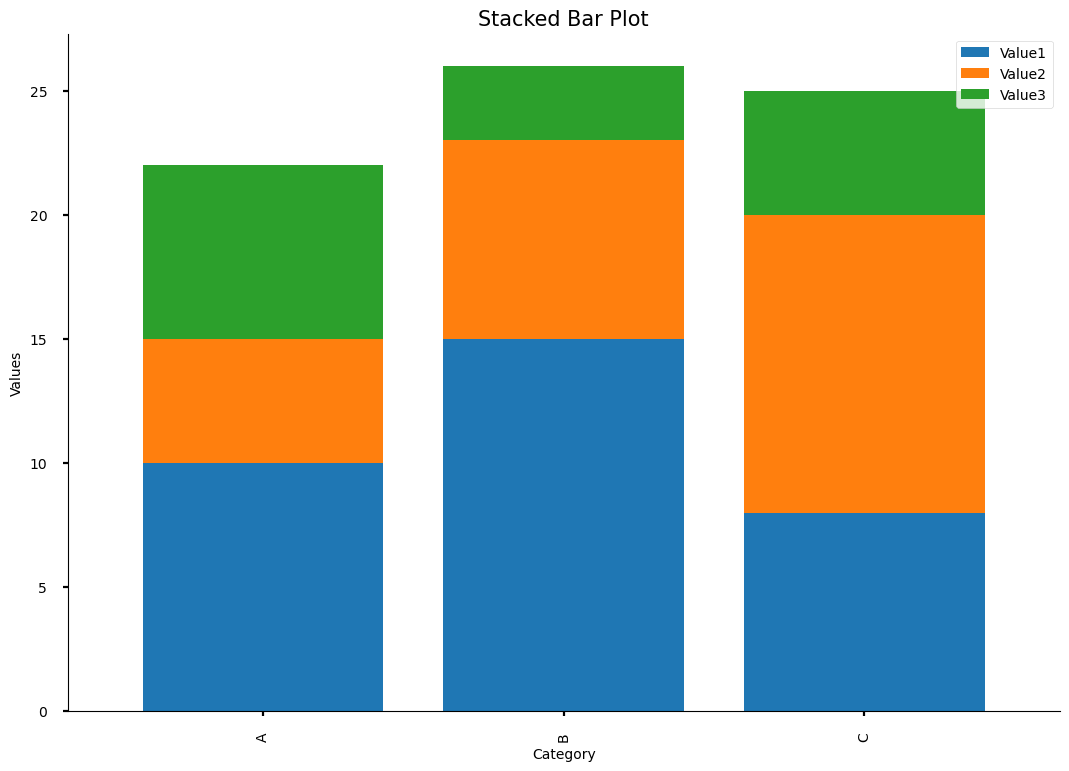

In [16]:
# Sample DataFrame
data = {'Category': ['A', 'B', 'C'],
        'Value1': [10, 15, 8],
        'Value2': [5, 8, 12],
        'Value3': [7, 3, 5]}
df = pd.DataFrame(data)

# Define colors for each column
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Example colors

# Create the stacked bar plot
df.plot(x='Category', kind='bar', stacked=True, color=colors, width=0.8)

# Customize the plot (optional)
plt.xlabel('Category')
plt.ylabel('Values')
plt.title('Stacked Bar Plot')
plt.legend(loc='upper right') 

plt.show()


In [37]:
color_dict

# colors = None
# if 'colors' in df.columns:
#     colors = []
#     for label in df_stacked.columns:
#         color = df_data[df_data['key']==label]['colors'].unique()
#         colors.extend(color)


colors = []
for key in df_data.columns:
    colors.append(color_dict[key])




['#dbdb8d',
 '#ffbb78',
 '#1f77b4',
 '#e377c2',
 '#c49c94',
 '#98df8a',
 '#bcbd22',
 '#8c564b',
 '#c5b0d5',
 '#2ca02c',
 '#9467bd',
 '#f7b6d2',
 '#17becf',
 '#7f7f7f',
 '#ff7f0e',
 '#d62728',
 '#8c564b',
 '#aec7e8',
 '#c7c7c7',
 '#ff9896',
 '#1f77b4']

AttributeError: Rectangle.set() got an unexpected keyword argument 'colors'

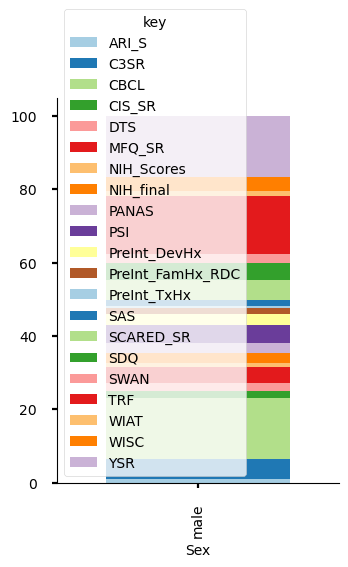

In [40]:
import matplotlib as mpl 

vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

# get data
dx = 'DX_ADHD'
model = 'december_adhd_dx'
df_keys = data_utils.load_topic_representation(model=model)

# make color dict for keys so that each key has a unique color
keys = df_keys['key'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(keys)))
colors_hex = [mpl.colors.to_hex(rgb) for rgb in colors]
color_dict = dict(zip(keys, colors_hex))

ax = fig.add_subplot(gs[0, 0])
df_data, colors, ax1 = fig1D(ax, 
    df_keys, 
    x='Sex',
    subplot='A', 
    feature='overall-selected_all', 
    Race=['all'],  
    target=dx, 
    development=['all'],
    target_cols=['ADHD (all comorbid.)'],
    features=['all-questions'],  
    sex=['male'],
    color_dict=color_dict,
    )
ax.set_xticklabels('')

# # get labels and colors from overall features
# labels1 = ax1.get_legend_handles_labels()[1]
# colors1 = [p.get_facecolor() for p in ax1.patches]
# df_ax1 = pd.DataFrame({'labels': labels1, 'colors': colors1})

# ax = fig.add_subplot(gs[0, 1])
# df_data, colors, ax2 = fig1D(ax, 
#     df_keys, 
#     x='Sex',
#     subplot='B', 
#     feature='selected_all', 
#     Race=['all'],  
#     target=dx, 
#     development=['all'],
#     target_cols=['ADHD (all comorbid.)'],
#     features=['all-questions'],  
#     sex=['male', 'female'],
#     colors=color_dict,
#     )

# # reassign colors for selected features
# labels2 = ax2.get_legend_handles_labels()[1]
# colors2 = df_ax1[df_ax1['labels'].isin(labels2)]['colors'].tolist()

# df_ax2 = pd.DataFrame({'labels': labels2, 'colors': colors2})
# df_keys_updated = df_keys.merge(df_ax2, left_on='key', right_on='labels')


## Participant DX across time

In [13]:
def filter_data(
          dx='DX_ADHD', 
          total_count='Age',
          ):
  # load data
  df = pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, 'participant_train_test.csv'))
  df.rename(columns={'PreInt_Demos_Fam,Child_Race_cat':'Race'}, inplace=True)

  if dx=='DX_Subtype_Name':
      # Use a boolean mask to identify rows where the diagnosis is not in the list of diagnoses to keep
      mask = ~df[dx].isin(['ADHD-Combined Type','ADHD-Inattentive Type', 
                          'Other Specified Attention-Deficit/Hyperactivity Disorder', 
                          'ADHD-Hyperactive/Impulsive Type',
                          'No Diagnosis Given'])
      # Replace the diagnoses in the masked rows with 'Other Diagnoses'
      df.loc[mask, dx] = 'other_diagnoses'
  elif dx=='DX_Cat_Name':
      # Use a boolean mask to identify rows where the diagnosis is not in the list of diagnoses to keep
      mask = ~df[dx].isin(['ADHD','Anxiety Disorders',
                           'Depressive Disorders',
                          'No Diagnosis Given'])
      # Replace the diagnoses in the masked rows with 'Other Diagnoses'
      df.loc[mask, dx] = 'Other diagnoses'

  # rename diagnoses
  if dx!='DX_Cat_Name':
    df[dx] = df[dx].map(utils.remap_dx())
  
  # filter data
  df1 = df.loc[df['Age_round']<=17].groupby('Identifiers').first().reset_index()
  df1['Age_round'] = df1['Age_round'].astype('int')

  # calculate female percentage
  df_filter = raw_scores.calculate_sex_percentage(df1, groupby_cols=['Age_round', dx], total_count=total_count)

  return df_filter


def Supp1(ax=None, 
          dx='DX_ADHD', 
          hue='Sex',
          dx_vals=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'Other diagnoses'],
          total_count='Age',
          sex=['male', 'female'],
          ):
  
  df_filter = filter_data(
              dx=dx, 
              total_count=total_count,
              )

  # plot female percentage across age and diagnosis
  data = df_filter[(df_filter[dx].isin(dx_vals))
                    & (df_filter['split'].isin(['train', 'test']))
                    & (df_filter['Sex'].isin(sex))
                  ]
  
  # plot
  if hue=='DX_ADHD_Sex':
    data[hue] = data['DX_ADHD'] + '-' + data['Sex']
    palette = sns.color_palette("Paired")
    rgb_palette = [tuple(color) for color in palette]
    palette = [rgb_palette[0], rgb_palette[0], rgb_palette[1], rgb_palette[1]]
    ax = sns.pointplot(x='Age_round', y='percent', data=data, hue=hue, palette=palette, 
                  markers=['+', 'v', '+', 'v'], linestyles=['--', '--', '--', '--'])
    ax.plot(markersize=3)
  else:
    sns.pointplot(x='Age_round', y='percent', data=data, hue=hue, linestyles='--')
  plt.xticks(rotation=45, ha='right'); 

  return data

def compare_slopes(df1, df2, alpha=0.05, x='Age_round', y='percent'):
    """
    Compares the slopes of two lines and determines if the difference is statistically significant.

    Args:
        df1, df2: Pandas DataFrames with 'x' and 'y' columns.
        alpha: Significance level for the t-test.
        x, y: Column names for the x and y variables.

    Returns:
        A tuple containing:
            - The steeper line (either 'df1' or 'df2')
            - A boolean indicating whether the difference is statistically significant
    """
    import pandas as pd
    from scipy.stats import linregress, ttest_ind
    import statsmodels.formula.api as smf

    # Calculate slopes using linear regression
    slope1 = linregress(df1[x], df1[y]).slope
    slope2 = linregress(df2[x], df2[y]).slope

    print(f'Slopes: {slope1:.3f} vs. {slope2:.3f}')
    # print(f'F statistic: {f_stat:.3f}, p-value: {p_value:.3f}')

def calculate_slopes(
    ax=None, 
    dx='DX_Cat_Name', 
    dx_vals=['ADHD'],
    total_count='Age',
    ):
    # filter data
    df_filter = filter_data(
            dx=dx, 
            total_count=total_count,
            )

    df1 = df_filter[(df_filter[dx].isin(dx_vals)) & (df_filter['Sex']=='female')]
    df2 = df_filter[(df_filter[dx].isin(dx_vals)) & (df_filter['Sex']=='male')]
    ax = sns.regplot(x='Age_round', y='percent', data=df1, scatter_kws={'alpha': 0.5}, ax=ax)
    ax = sns.regplot(x='Age_round', y='percent', data=df2, scatter_kws={'alpha': 0.5}, ax=ax)
    plt.xticks(rotation=45, ha='right'); 
    plt.xlabel('Age')
    plt.ylabel(f'{dx_vals[0]} (% relative to all diagnoses)')

    compare_slopes(df1, df2, alpha=0.05, x='Age_round', y='percent')



Slopes: -1.855 vs. -1.359
Slopes: 2.255 vs. 1.137


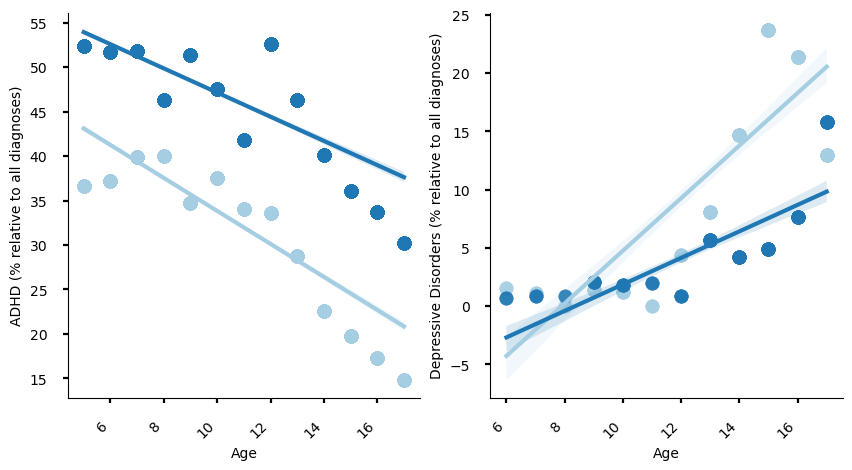

In [50]:
vis.plotting_style()
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
calculate_slopes(ax=ax, dx='DX_Cat_Name', dx_vals=['ADHD'])

ax = fig.add_subplot(gs[0, 1])
calculate_slopes(ax=ax, dx='DX_Cat_Name', dx_vals=['Depressive Disorders'])

Slopes: -1.277 vs. -1.807
Slopes: -0.086 vs. 1.150


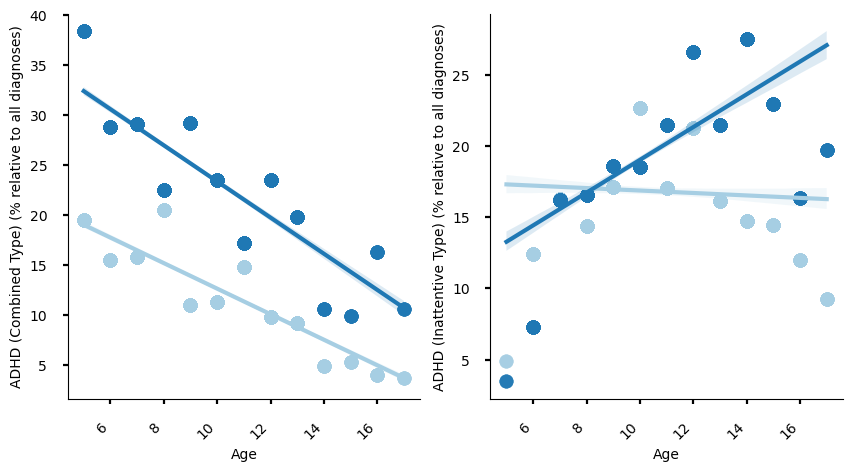

In [53]:
vis.plotting_style()
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
calculate_slopes(ax=ax, dx='DX_Subtype_Name', dx_vals=['ADHD (Combined Type)'])

ax = fig.add_subplot(gs[0, 1])
calculate_slopes(ax=ax, dx='DX_Subtype_Name', dx_vals=['ADHD (Inattentive Type)'])


### Supp Fig. 2

What % of female percentages (relative to male) are diagnosed across age? 

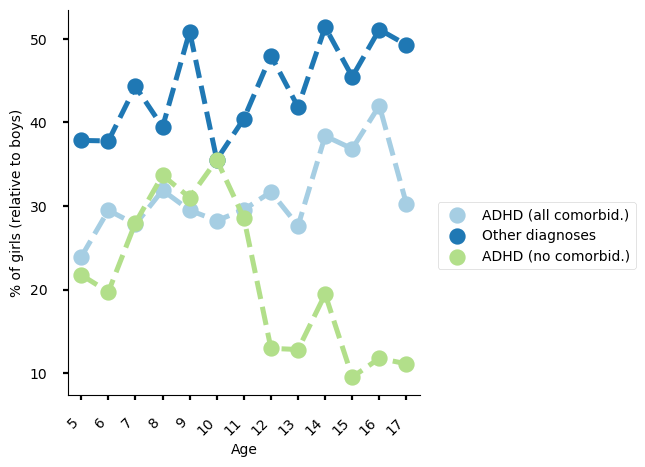

In [19]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 2, figure=fig)
ax = fig.add_subplot(gs[0, 0])
Supp1(ax, dx='DX_ADHD', dx_vals=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'Other diagnoses'], total_count='Sex', hue='DX_ADHD', sex=['female'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylabel('% of girls (relative to boys)')
ax.set_xlabel('Age');

fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp2-adhd.png'), bbox_inches='tight')



### Supp Fig. 3

For each year, what are the numbers of females diagnosed with ADHD (subtypes) relative to all possible diagnoses? 

Can we compare ADHD diagnosis with other common diagnoses (anxiety, depression etc.)?

What about pure ADHD diagnosis? what % of females have a pure ADHD diagnosis relative to all other possible diagnoses? (and compare that for boys)

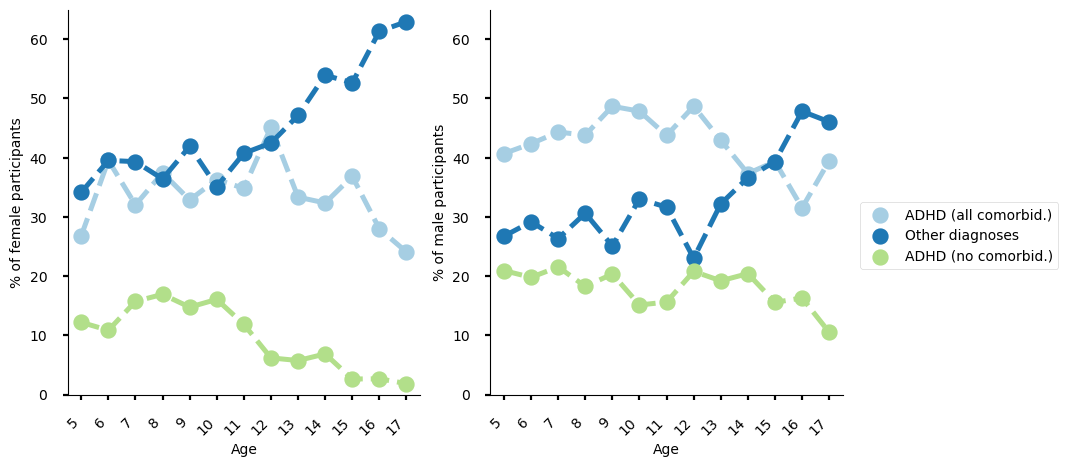

In [20]:
# # plot
vis.plotting_style()
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 2, figure=fig)
ax = fig.add_subplot(gs[0, 0])
Supp1(ax, dx='DX_ADHD', total_count='Age', dx_vals=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'Other diagnoses'], hue='DX_ADHD', sex=['female'])
ax.get_legend().remove()
ax.set_ylim([0, 65])
ax.set_ylabel('% of female participants')
ax.set_xlabel('Age');

ax = fig.add_subplot(gs[0, 1])
Supp1(ax, dx='DX_ADHD', total_count='Age', dx_vals=['ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'Other diagnoses'], hue='DX_ADHD', sex=['male'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylim([0, 65])
ax.set_ylabel('% of male participants')
ax.set_xlabel('Age');

# fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp2-adhd.png'), bbox_inches='tight')



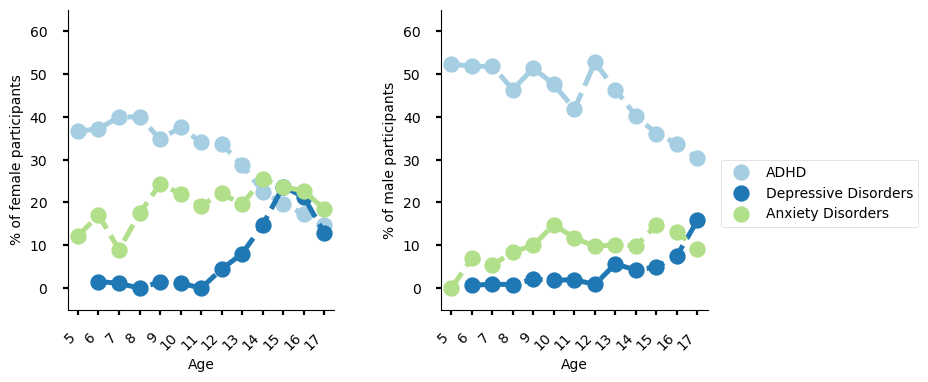

In [16]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)


ax = fig.add_subplot(gs[0, 0])
Supp1(ax, dx='DX_Cat_Name', total_count='Age', dx_vals=['Anxiety Disorders', 'ADHD', 'Depressive Disorders'], hue='DX_Cat_Name', sex=['female'])
ax.get_legend().remove()
ax.set_ylim([-5, 65])
ax.set_ylabel('% of female participants')
ax.set_xlabel('Age');


ax = fig.add_subplot(gs[0, 1])
Supp1(ax, dx='DX_Cat_Name', total_count='Age', dx_vals=['Anxiety Disorders', 'ADHD', 'Depressive Disorders'], hue='DX_Cat_Name', sex=['male'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylim([-5, 65])
ax.set_ylabel('% of male participants')
ax.set_xlabel('Age');

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.7, 
                    wspace=0.4, 
                    hspace=0.4)

# fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp2-adhd.png'), bbox_inches='tight')


In [66]:

palette = sns.color_palette("Paired")
rgb_palette = [tuple(color) for color in palette]

palette = [rgb_palette[0], rgb_palette[0], rgb_palette[1], rgb_palette[1]]

(0.6509803921568628, 0.807843137254902, 0.8901960784313725)

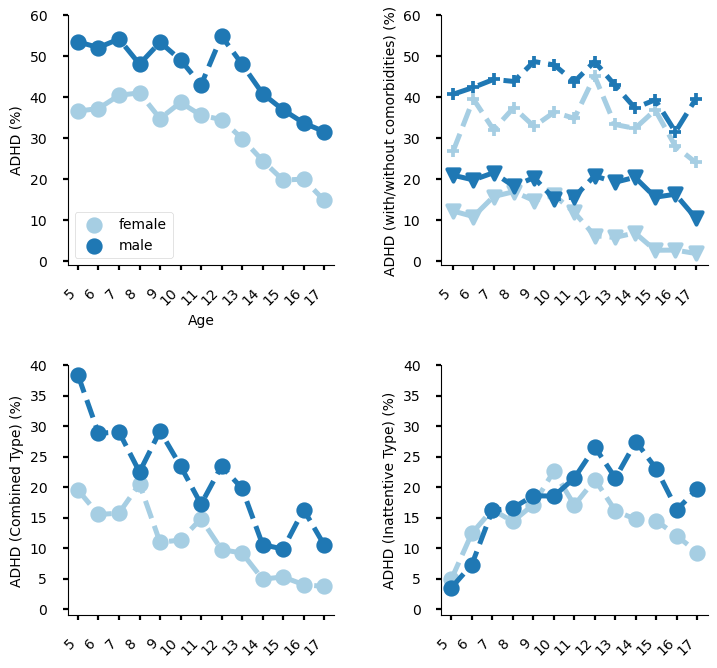

In [10]:

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,10))
gs = GridSpec(2, 2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
Supp1(ax, dx='DX_Cat_Name', total_count='Age', dx_vals=['ADHD'],  sex=['female', 'male'], hue='Sex')
ax.legend().set_title('')
ax.set_ylim([-1, 60])
ax.set_ylabel('ADHD (%)')
ax.set_xlabel('Age');

ax = fig.add_subplot(gs[0, 1])
Supp1(ax, dx='DX_ADHD', total_count='Age', dx_vals=['ADHD (all comorbid.)', 'ADHD (no comorbid.)'],  hue='DX_ADHD_Sex', sex=['male', 'female'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.legend().remove()
ax.set_ylim([-1, 60])
ax.set_ylabel('ADHD (with/without comorbidities) (%)')
ax.set_xlabel('');

ax = fig.add_subplot(gs[1, 0])
Supp1(ax, dx='DX_Subtype_Name', total_count='Age', dx_vals=['ADHD (Combined Type)'],  hue='Sex', sex=['male', 'female'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylim([-1, 40])
ax.legend().remove()
ax.set_xlabel('')
ax.set_ylabel('ADHD (Combined Type) (%)')
ax.set_xlabel('');

ax = fig.add_subplot(gs[1, 1])
Supp1(ax, dx='DX_Subtype_Name', total_count='Age', dx_vals=['ADHD (Inattentive Type)'],  hue='Sex', sex=['male', 'female'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylim([-1, 40])
ax.legend().remove()
ax.set_xlabel('')
ax.set_ylabel('ADHD (Inattentive Type) (%)')
ax.set_xlabel('');

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.7, 
                    wspace=0.4, 
                    hspace=0.4)

# fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp2-adhd.png'), bbox_inches='tight')


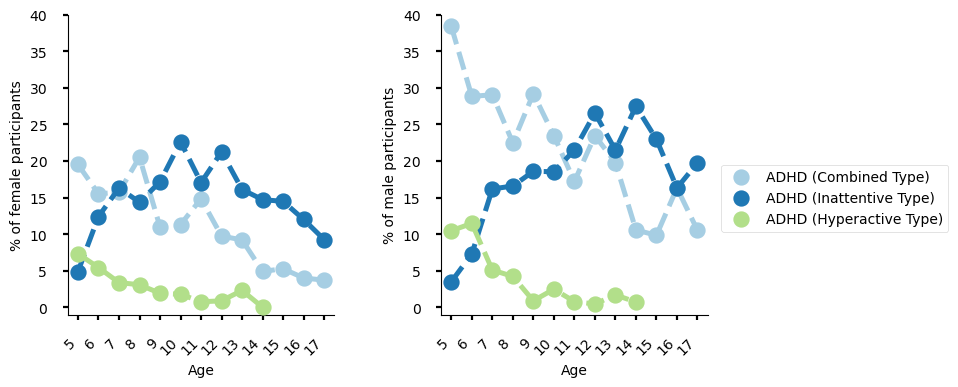

In [51]:
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 2, figure=fig)

ax = fig.add_subplot(gs[0, 0])
Supp1(ax, dx='DX_Subtype_Name', total_count='Age', dx_vals=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'], hue='DX_Subtype_Name', sex=['female'])
ax.get_legend().remove()
ax.set_ylim([-1, 40])
ax.set_ylabel('% of female participants')
ax.set_xlabel('Age');

ax = fig.add_subplot(gs[0, 1])
Supp1(ax, dx='DX_Subtype_Name', total_count='Age', dx_vals=['ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)'],  hue='DX_Subtype_Name', sex=['male'])
ax.legend(bbox_to_anchor=(1.05, .5), loc=2, borderaxespad=0.0)
ax.set_ylim([-1, 40])
ax.set_ylabel('% of male participants')
ax.set_xlabel('Age');


plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.7, 
                    wspace=0.4, 
                    hspace=0.4)

### Supp 4.

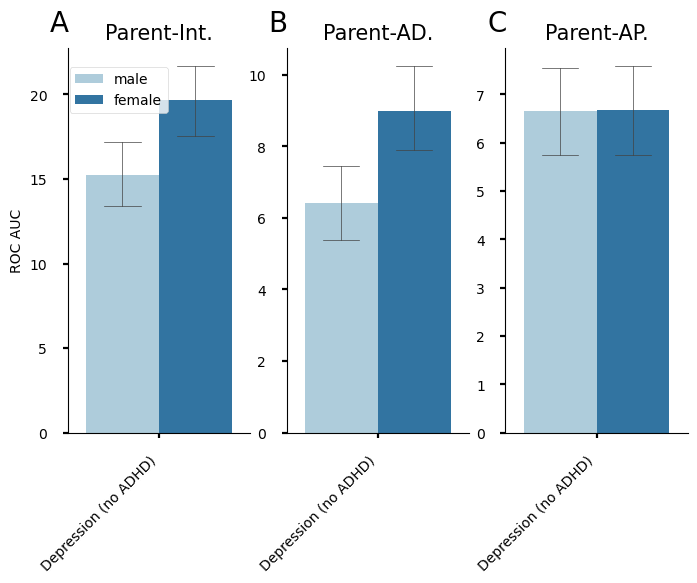

In [41]:


# df = raw_scores.load_parent_child_teacher(
#     key=['AP', 'Int', 'AD', 'WD', 'SP', 'TP', 'RBB', 'AB'],     
#     dx='DX_Depression', 
#     dx_to_include=['Depression (no ADHD)']
#     )

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,5))
gs = GridSpec(1, 3, figure=fig)

plot_dict = {'A': ['CBCL,CBCL_Int', (0,0), True, 'Parent-Int.', (.01, .95), 'ROC AUC'],
            'B': ['CBCL,CBCL_AD', (0,1), False, 'Parent-AD.', (.01,.8), ''],
            'C': ['CBCL,CBCL_AP', (0,2), False, 'Parent-AP.', (.01,.8), ''],
            # 'D': ['CBCL,CBCL_AD', (1,1), True, 'Parent-AD.', (.01, .95)],
            # 'E': ['CBCL,CBCL_WD', (2,0), True, 'Parent-WD.', (.01,.8)],
            # 'F': ['CBCL,CBCL_SP', (2,1), True, 'Parent-SP.', (.01,.8)],
            # 'G': ['CBCL,CBCL_TP', (3,0), True, 'Parent-TP.', (.01,.8)],
            # 'H': ['CBCL,CBCL_RBB', (3,1), True, 'Parent-RBB.', (.01,.8)],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    vis.barplot(x='DX_Depression', y=value[0], hue='Sex', 
                    data=df, ax=ax, ylim=None, subplot=key, 
                    bbox_to_anchor=value[4], ylabel=value[5],
                    title=value[3], legend=value[2])
    
# fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)
fig.savefig(os.path.join(Defaults.FIG_DIR, f'Supp4.png'), bbox_inches='tight')


## Plot Raw Scores across Age for CBCL subscales

what are we interested in here? 

are inattention scores higher for girls with depression (but no ADHD diagnois) compared to boys with same diagnosis? 

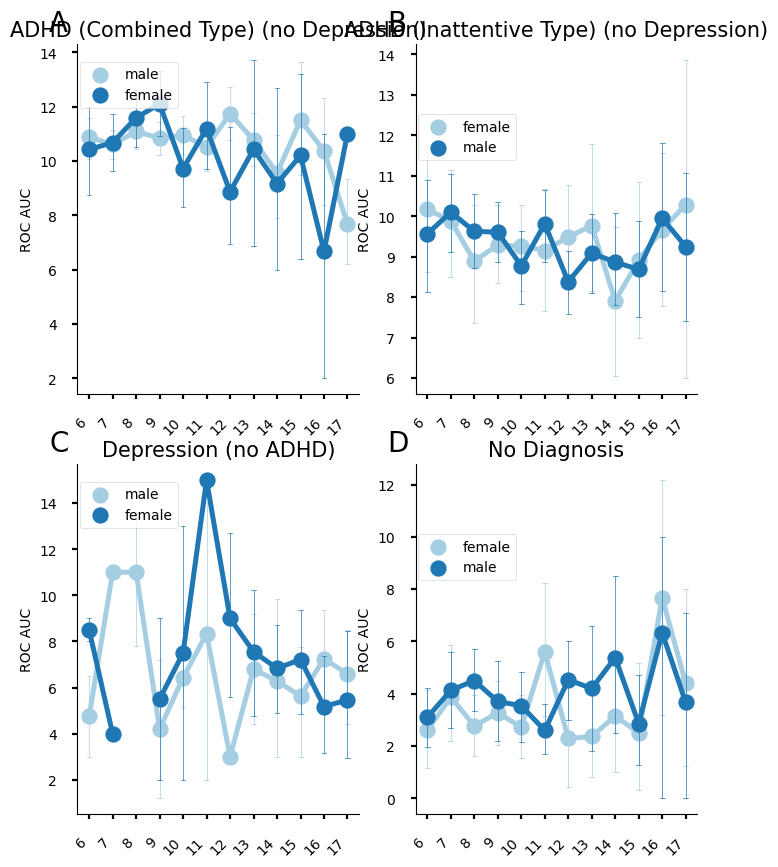

In [25]:

# df = raw_scores.load_parent_child_teacher(
#     key=['AP'],     
#     dx='DX_ADHD', 
#     dx_to_include=['ADHD (Combined Type) (no Depression)','ADHD (Inattentive Type) (no Depression)', 'Depression (no ADHD)', 'No Diagnosis']
#     )

# # plot
vis.plotting_style()
fig = plt.figure(figsize=(8,10))
gs = GridSpec(2, 2, figure=fig)

plot_dict = {'A': ['CBCL,CBCL_AP', (0,0), True, 'ADHD (Combined Type) (no Depression)', (.01, .95)],
            'B': ['CBCL,CBCL_AP', (0,1), True, 'ADHD (Inattentive Type) (no Depression)', (.01,.8)],
            'C': ['CBCL,CBCL_AP', (1,0), True, 'Depression (no ADHD)', (.01, .95)],
            'D': ['CBCL,CBCL_AP', (1,1), True, 'No Diagnosis', (.01,.8)],
            }

for i, (key, value) in enumerate(plot_dict.items()):
    ax = fig.add_subplot(gs[plot_dict[key][1]])
    df1 = df[df['DX_Depression']==value[3]]
    vis.pointplot(x='Age_round', y=value[0], hue='Sex', 
                    data=df1, ax=ax, ylim=None, subplot=key, 
                    bbox_to_anchor=value[4],
                    title=value[3], legend=value[2])
    
# fig.subplots_adjust(left=0.125, bottom=0.001, right=6.8, top=2.0, wspace=.2, hspace=.3)


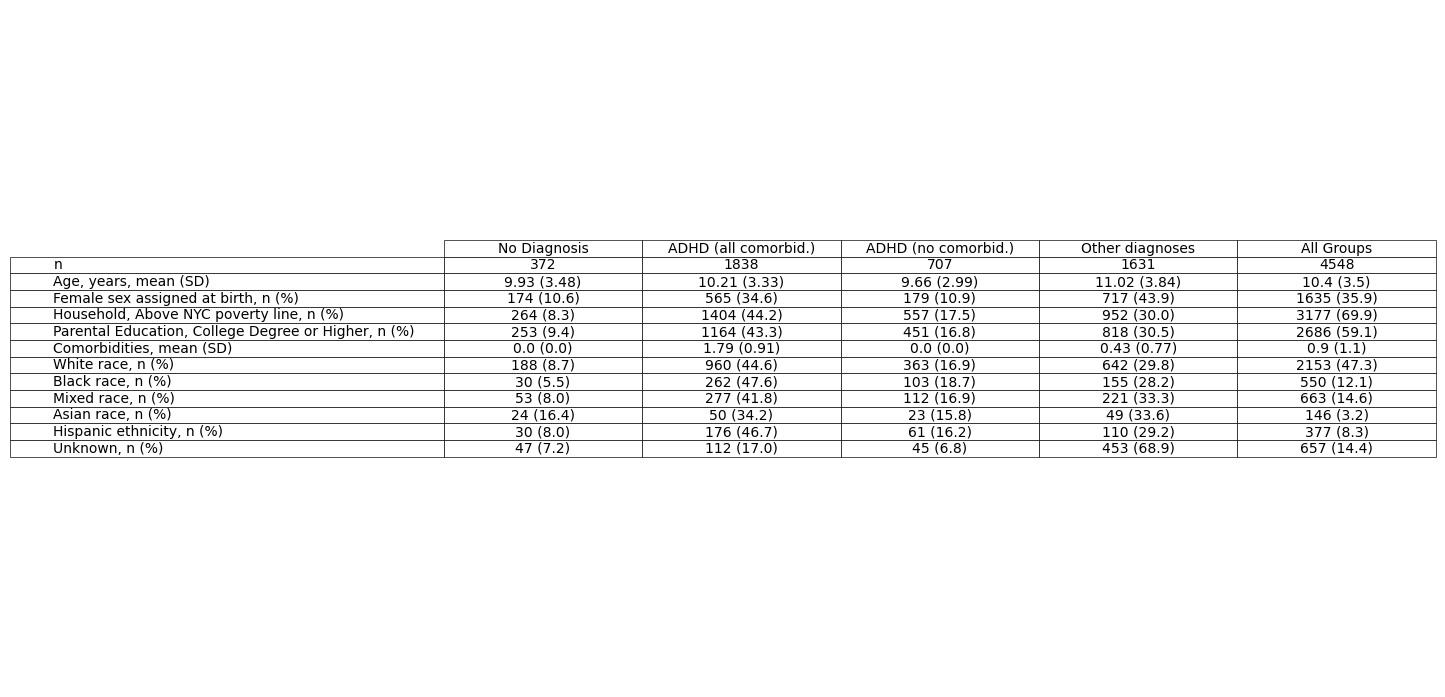

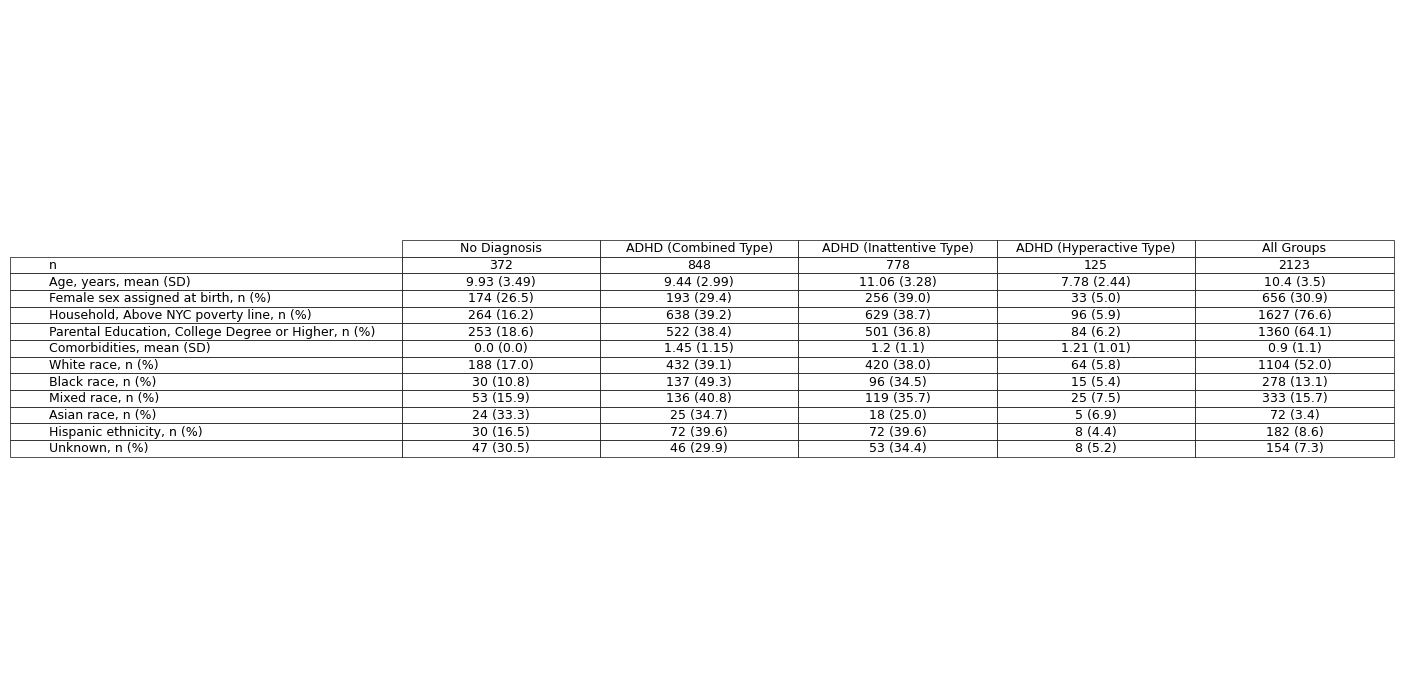

In [36]:
from hbn.visualization.make_tables import make_table_1, make_table_2

make_table_1(split='DX_ADHD', 
             split_vals=['No Diagnosis', 'ADHD (all comorbid.)', 'ADHD (no comorbid.)', 'Other diagnoses']
             )

make_table_1(split='DX_Subtype_Name', 
            split_vals=['No Diagnosis', 'ADHD (Combined Type)', 'ADHD (Inattentive Type)', 'ADHD (Hyperactive Type)']
            )
